# 03 - Aprendizaje No Supervisado (Students, version mejorada)

Este notebook construye clusters con K-Modes y agrega visualizaciones avanzadas: geometria (PCA/t-SNE), radar de perfiles y composicion demografica.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kmodes.kmodes import KModes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'reports').exists():
            return p
    raise RuntimeError('No se encontro la raiz del proyecto')

ROOT = find_project_root(Path.cwd().resolve())
print('Project root:', ROOT)

Project root: /home/raul/Documents/courses/unsa/machine-learning


In [12]:
path = ROOT / 'data/processed/students/students_limpio.csv'
out_path = ROOT / 'data/processed/students/students_clusterizado.csv'
fig_dir = ROOT / 'reports/students/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(path)

numericas = [
    'edad', 'semestre_actual', 'horas_estudio_diario', 'horas_redes_sociales_diario',
    'asistencia_promedio_clase', 'horas_desarrollo_habilidades_diario',
    'sgpa_previo', 'cgpa_actual', 'creditos_completados', 'ingreso_familiar_mensual'
]
for c in numericas:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

features = [
    'sexo', 'programa', 'modo_aprendizaje_preferido', 'nivel_ingles',
    'habilidades_principales', 'area_interes', 'convivencia', 'alguna_vez_probation'
]
X = df[features].fillna('Unknown').astype(str).copy()

label_maps = {}
for c in X.columns:
    cats = sorted(X[c].unique().tolist())
    mapping = {v: i for i, v in enumerate(cats)}
    label_maps[c] = mapping
    X[c] = X[c].map(mapping)

print('Shape para clustering:', X.shape)

Shape para clustering: (1194, 8)


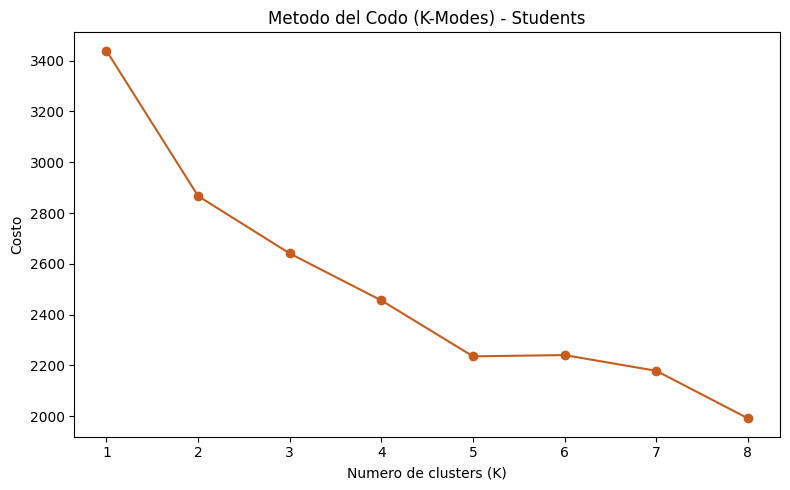

Costos por K: {1: 3439.0, 2: 2867.0, 3: 2641.0, 4: 2456.0, 5: 2236.0, 6: 2241.0, 7: 2179.0, 8: 1992.0}


In [13]:
# Metodo del codo para elegir K
k_values = list(range(1, 9))
costos = []
for k in k_values:
    m = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
    m.fit(X)
    costos.append(float(m.cost_))

plt.figure(figsize=(8, 5))
plt.plot(k_values, costos, marker='o', color='#c65d1e')
plt.title('Metodo del Codo (K-Modes) - Students')
plt.xlabel('Numero de clusters (K)')
plt.ylabel('Costo')
plt.tight_layout()
plt.savefig(fig_dir / '04_curva_elbow_students.png', dpi=150)
plt.show()

print('Costos por K:', dict(zip(k_values, costos)))

In [14]:
# Entrenamiento final
k_opt = 4
km_final = KModes(n_clusters=k_opt, init='Huang', n_init=10, random_state=42)
clusters = km_final.fit_predict(X)

df['cluster_kmodes'] = clusters
df['cluster'] = clusters

# Variables derivadas para perfiles

df['puntaje_recursos'] = (
    df['usa_smartphone'].astype(str).str.lower().eq('yes').astype(int)
    + df['tiene_computadora_personal'].astype(str).str.lower().eq('yes').astype(int)
)
df['ratio_estudio_social'] = df['horas_estudio_diario'] / (df['horas_redes_sociales_diario'].replace(0, np.nan) + 1)
df['horas_productivas_totales'] = df['horas_estudio_diario'].fillna(0) + df['horas_desarrollo_habilidades_diario'].fillna(0)
df['momentum_academico'] = df['cgpa_actual'] - df['sgpa_previo']

df.to_csv(out_path, index=False)
print('Archivo clusterizado guardado en:', out_path)
print(df['cluster'].value_counts().sort_index())

Archivo clusterizado guardado en: /home/raul/Documents/courses/unsa/machine-learning/data/processed/students/students_clusterizado.csv
cluster
0    388
1    443
2    200
3    163
Name: count, dtype: int64


Computando t-SNE (demora aprox. 20-40 segundos)...


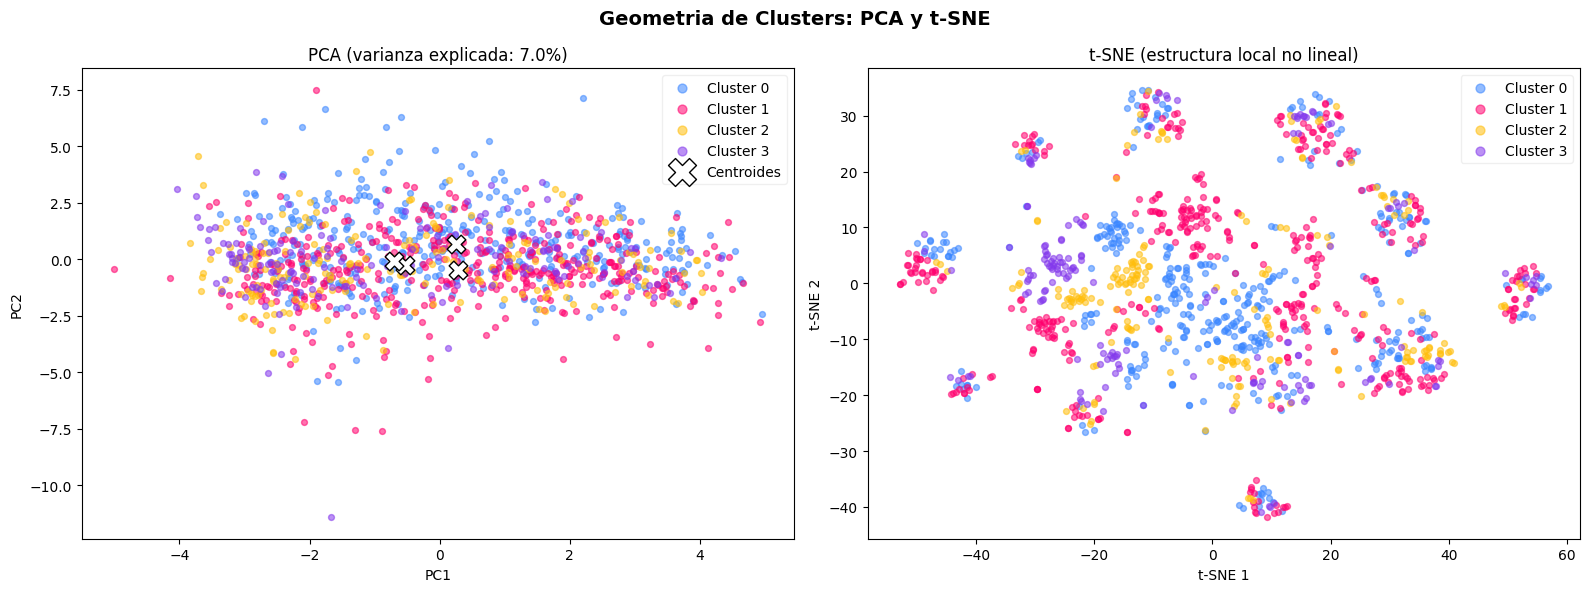

In [15]:
# Visualizacion geometrica: PCA + t-SNE
geom_features = features + [
    'edad', 'semestre_actual', 'horas_estudio_diario', 'horas_redes_sociales_diario',
    'asistencia_promedio_clase', 'sgpa_previo', 'cgpa_actual', 'creditos_completados',
    'ingreso_familiar_mensual', 'puntaje_recursos', 'ratio_estudio_social',
    'horas_productivas_totales', 'momentum_academico'
]
geom_df = df[geom_features].copy()
for c in geom_df.columns:
    if c in features:
        geom_df[c] = geom_df[c].fillna('Unknown').astype(str)
    else:
        geom_df[c] = pd.to_numeric(geom_df[c], errors='coerce').fillna(geom_df[c].median())

X_geom = pd.get_dummies(geom_df, columns=features, drop_first=False)
X_scaled = StandardScaler().fit_transform(X_geom)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('Computando t-SNE (demora aprox. 20-40 segundos)...')
tsne = TSNE(n_components=2, perplexity=35, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

cluster_ids = sorted(df['cluster'].unique())
CLUSTER_COLORS = ['#3a86ff', '#ff006e', '#ffbe0b', '#8338ec', '#06d6a0']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geometria de Clusters: PCA y t-SNE', fontsize=14, fontweight='bold')

for cluster_id, color in zip(cluster_ids, CLUSTER_COLORS):
    mask = df['cluster'] == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.55, s=18, label=f'Cluster {cluster_id}')

centroids_pca = np.array([X_pca[df['cluster'] == cid].mean(axis=0) for cid in cluster_ids])
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='white', s=180, marker='X', zorder=5, edgecolors='black', linewidth=1, label='Centroides')
axes[0].set_title(f'PCA (varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(framealpha=0.3, markerscale=1.5)

for cluster_id, color in zip(cluster_ids, CLUSTER_COLORS):
    mask = df['cluster'] == cluster_id
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, alpha=0.55, s=18, label=f'Cluster {cluster_id}')

axes[1].set_title('t-SNE (estructura local no lineal)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(framealpha=0.3, markerscale=1.5)

plt.tight_layout()
plt.savefig(fig_dir / '06_cluster_geometry_students.png', dpi=150, bbox_inches='tight')
plt.show()

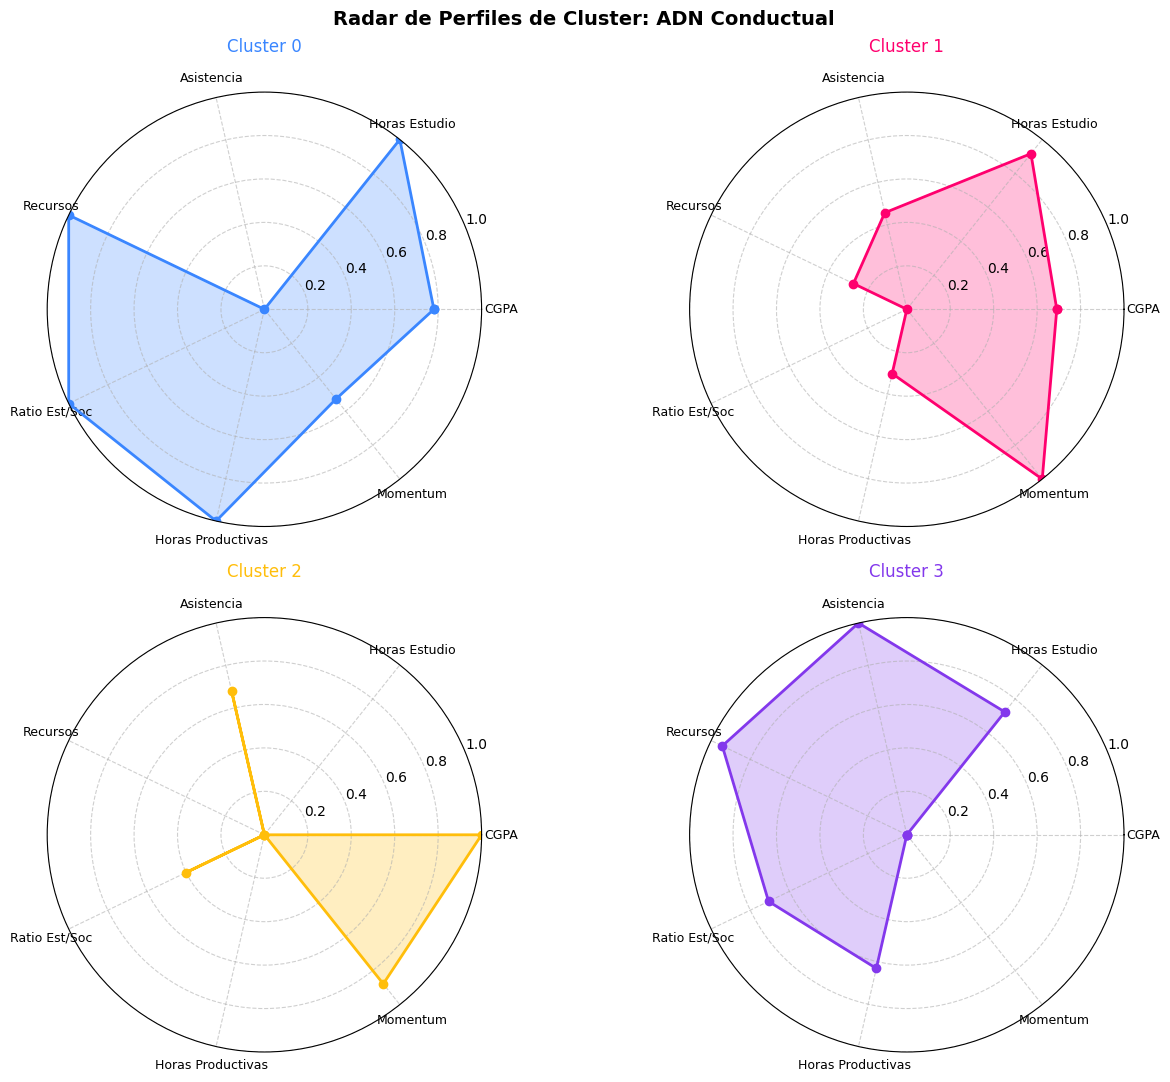

In [16]:
# Radar de perfiles por cluster
radar_features = [
    'cgpa_actual', 'horas_estudio_diario', 'asistencia_promedio_clase',
    'puntaje_recursos', 'ratio_estudio_social', 'horas_productivas_totales', 'momentum_academico'
]
radar_labels = ['CGPA', 'Horas Estudio', 'Asistencia', 'Recursos', 'Ratio Est/Soc', 'Horas Productivas', 'Momentum']

cluster_means = df.groupby('cluster')[radar_features].mean()
den = (cluster_means.max() - cluster_means.min()).replace(0, 1)
cluster_means_norm = (cluster_means - cluster_means.min()) / den

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(13, 11), subplot_kw=dict(polar=True))
fig.suptitle('Radar de Perfiles de Cluster: ADN Conductual', fontsize=14, fontweight='bold')

for idx, (cluster_id, color) in enumerate(zip(sorted(df['cluster'].unique()), CLUSTER_COLORS)):
    ax = axes[idx // 2][idx % 2]
    values = cluster_means_norm.loc[cluster_id].values.tolist()
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, color=color)
    ax.fill(angles, values, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}', size=12, color=color, pad=15)
    ax.grid(linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(fig_dir / '07_radar_profiles_students.png', dpi=150, bbox_inches='tight')
plt.show()

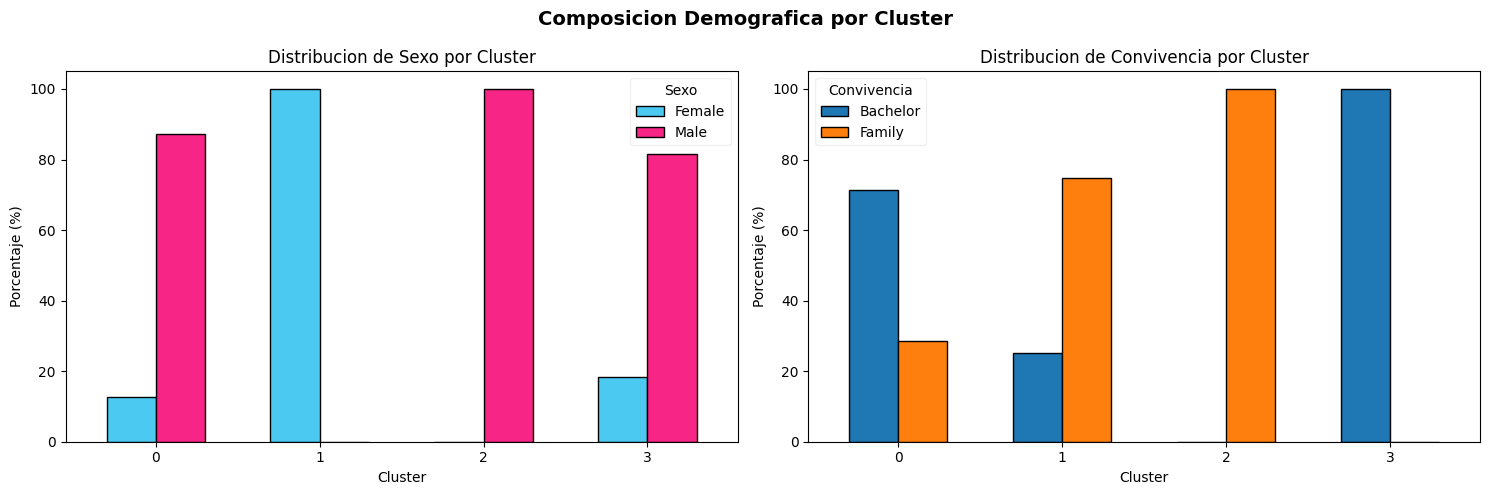

In [17]:
# Composicion demografica por cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Composicion Demografica por Cluster', fontsize=14, fontweight='bold')

sexo_cross = df.groupby(['cluster', 'sexo']).size().unstack(fill_value=0)
sexo_pct = sexo_cross.div(sexo_cross.sum(axis=1), axis=0) * 100
sexo_pct.plot(kind='bar', ax=axes[0], color=['#4cc9f0', '#f72585'], edgecolor='black', width=0.6)
axes[0].set_title('Distribucion de Sexo por Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sexo', framealpha=0.3)

conv_cross = df.groupby(['cluster', 'convivencia']).size().unstack(fill_value=0)
conv_pct = conv_cross.div(conv_cross.sum(axis=1), axis=0) * 100
conv_pct.plot(kind='bar', ax=axes[1], edgecolor='black', width=0.6)
axes[1].set_title('Distribucion de Convivencia por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Convivencia', framealpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / '08_demographic_breakdown_students.png', dpi=150, bbox_inches='tight')
plt.show()